# Salary Analysis: A Statistical Study Using ANOVA and Regression

## Project Overview

This project analyzes employee salary data using statistical methods including
Simple Linear Regression, ANOVA, Multiple Regression, ANCOVA, and Interaction Models.
The goal is to identify which employee characteristics, both quantitative and categorical, have a statistically significant effect on salary.

## Dataset

The dataset contains 789 observations and 10 variables covering employee demographics,
work experience, performance, and compensation.


## Cell 1 — Load the Dataset

The dataset is loaded from Google Colab's file explorer using read.csv().
The stringsAsFactors = TRUE argument ensures all character columns are
automatically converted to factors, which is required for ANOVA and
categorical regression models.

In [ ]:
df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

dim(df)
str(df)
head(df)

[1] 789  10

'data.frame':	789 obs. of  10 variables:
 $ Salary           : num  59281 116911 112958 117415 102152 ...
 $ ExperienceYears  : int  3 28 19 24 24 16 12 16 30 4 ...
 $ TrainingHours    : int  59 89 22 31 47 26 94 88 97 97 ...
 $ PerformanceRating: int  1 4 1 2 1 1 4 2 4 4 ...
 $ Age              : int  27 25 58 36 22 34 52 35 50 41 ...
 $ ProjectsCompleted: int  7 8 9 0 8 9 19 2 5 8 ...
 $ EducationLevel   : Factor w/ 4 levels "Bachelors","HighSchool",..: 1 3 4 4 2 2 4 4 2 1 ...
 $ Department       : Factor w/ 5 levels "Finance","HR",..: 1 4 2 3 5 1 1 1 2 4 ...
 $ Gender           : Factor w/ 3 levels "Female","Male",..: 1 2 2 1 1 3 2 3 2 2 ...
 $ JobLevel         : Factor w/ 4 levels "Junior","Lead",..: 1 2 2 3 4 1 1 2 3 2 ...


,Salary,ExperienceYears,TrainingHours,PerformanceRating,Age,ProjectsCompleted,EducationLevel,Department,Gender,JobLevel
,<dbl>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>
1,59280.63,3,59,1,27,7,Bachelors,Finance,Female,Junior
2,116911.13,28,89,4,25,8,Masters,Marketing,Male,Lead
3,112957.56,19,22,1,58,9,PhD,HR,Male,Lead
4,117414.91,24,31,2,36,0,PhD,IT,Female,Mid
5,102151.69,24,47,1,22,8,HighSchool,Sales,Female,Senior
6,83975.64,16,26,1,34,9,HighSchool,Finance,Other,Junior


## Cell 2 — Data Cleaning

Before any analysis, the dataset must be inspected and cleaned to ensure
data quality and correct variable types.

The following steps are performed:

**1. Missing Value Check**
The entire dataframe is scanned for NA values, both in total and per column.
Any rows containing missing values are removed using na.omit().

**2. Factor Ordering**
Two categorical variables have a natural ordering that must be explicitly defined:

- EducationLevel: High School < Bachelor's < Master's < PhD
- JobLevel: Junior < Mid < Senior < Lead

Defining these as ordered factors ensures R treats them correctly in
regression models and produces meaningful coefficient interpretations.

**3. Summary Check**
A final summary() confirms the cleaned dataset's structure, factor levels,
and the range of all numeric variables before proceeding to analysis.

In [ ]:
df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

sum(is.na(df))

colSums(is.na(df))

df = na.omit(df)

df$EducationLevel = factor(df$EducationLevel, levels = c("High School", "Bachelor's", "Master's", "PhD"))
df$JobLevel = factor(df$JobLevel, levels = c("Junior", "Mid", "Senior", "Lead"))
df$Department = factor(df$Department)
df$Gender = factor(df$Gender)

summary(df)

[1] 0

Salary   ExperienceYears     TrainingHours PerformanceRating 
                0                 0                 0                 0 
              Age ProjectsCompleted    EducationLevel        Department 
                0                 0                 0                 0 
           Gender          JobLevel 
                0                 0

     Salary       ExperienceYears TrainingHours   PerformanceRating
 Min.   : 43226   Min.   : 0.00   Min.   :  0.0   Min.   :1.000    
 1st Qu.: 82407   1st Qu.: 7.00   1st Qu.: 23.0   1st Qu.:2.000    
 Median : 95451   Median :15.00   Median : 48.0   Median :3.000    
 Mean   : 96188   Mean   :15.06   Mean   : 48.6   Mean   :2.958    
 3rd Qu.:109931   3rd Qu.:23.00   3rd Qu.: 74.0   3rd Qu.:4.000    
 Max.   :150717   Max.   :30.00   Max.   :100.0   Max.   :5.000    
      Age        ProjectsCompleted     EducationLevel     Department 
 Min.   :21.00   Min.   : 0.000    High School:  0    Finance  :150  
 1st Qu.:30.00   1st Qu.: 5.000    Bachelor's :  0    HR       :170  
 Median :40.00   Median :10.000    Master's   :  0    IT       :143  
 Mean   :40.46   Mean   : 9.875    PhD        :207    Marketing:143  
 3rd Qu.:51.00   3rd Qu.:15.000    NA's       :582    Sales    :183  
 Max.   :60.00   Max.   :20.000                                      
    Gender      JobLevel  
 Female

## Cell 3 — Exploratory Data Analysis (EDA)

Before building any models, we visually explore the data to understand
distributions, group differences, and relationships between variables.

### What is Examined

**Histograms — Numeric Variable Distributions**
- Salary is approximately bell-shaped and centered around $95,000 to $105,000
  with a slight right skew, which is acceptable for regression analysis.
- Experience Years and Training Hours are roughly uniformly distributed.
- Age shows a concentration in the early 20s, then flattens out.

**Boxplots — Salary by Categorical Group**
- Job Level shows the clearest and most consistent salary increase from
  Junior to Lead, making it the strongest categorical predictor.
- Department shows overlapping distributions across Finance, HR, IT,
  Marketing, and Sales, suggesting group differences may not be significant.
- Gender shows nearly identical medians and spreads across Female, Male,
  and Other, indicating Gender is unlikely to be a strong predictor.
- Education Level shows data concentrated in the PhD category, with
  limited representation in other levels.

**Correlation Matrix and Scatterplot Matrix**
- ExperienceYears has the strongest positive linear relationship with Salary,
  making it the best candidate for Simple Linear Regression.
- ProjectsCompleted and Age show moderate scatter with Salary.
- PerformanceRating is discrete (1 to 5) and shows banded patterns.
- No strong multicollinearity is detected among the predictors.

### Modeling Decisions Based on EDA

| Analysis | Model | Justification |
|---|---|---|
| Simple Linear Regression | Salary ~ ExperienceYears | Strongest linear relationship |
| ANOVA | Salary ~ JobLevel | Clearest group salary differences |
| Multiple Regression | Salary ~ all numeric predictors | Capture combined effects |
| ANCOVA | Salary ~ ExperienceYears + JobLevel | Control for job level |
| Interaction Model | Salary ~ ExperienceYears * JobLevel | Test if slope differs by level |

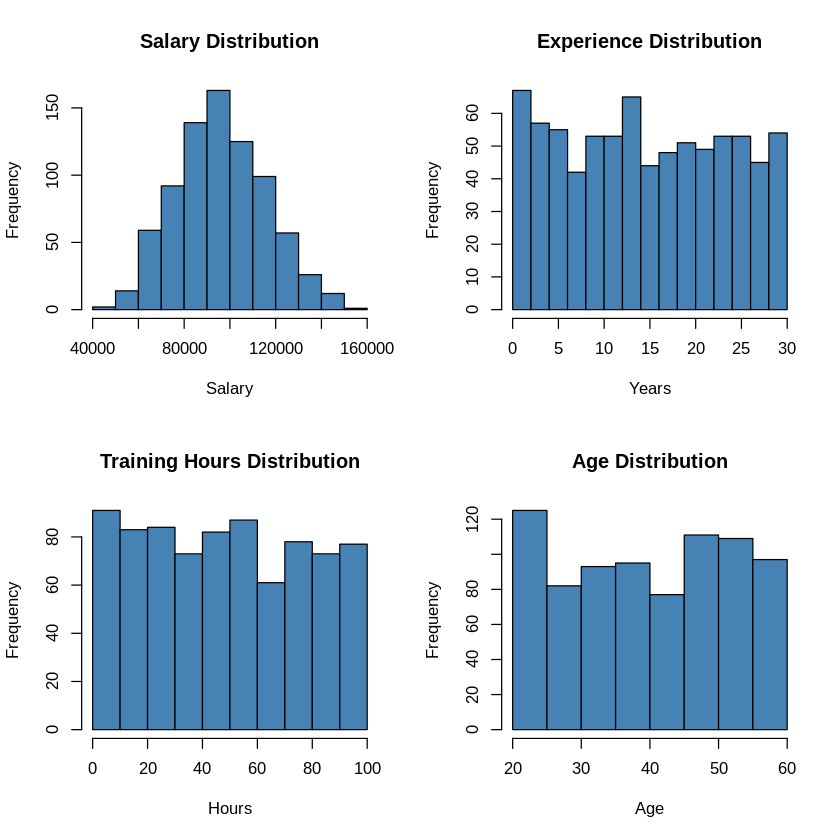

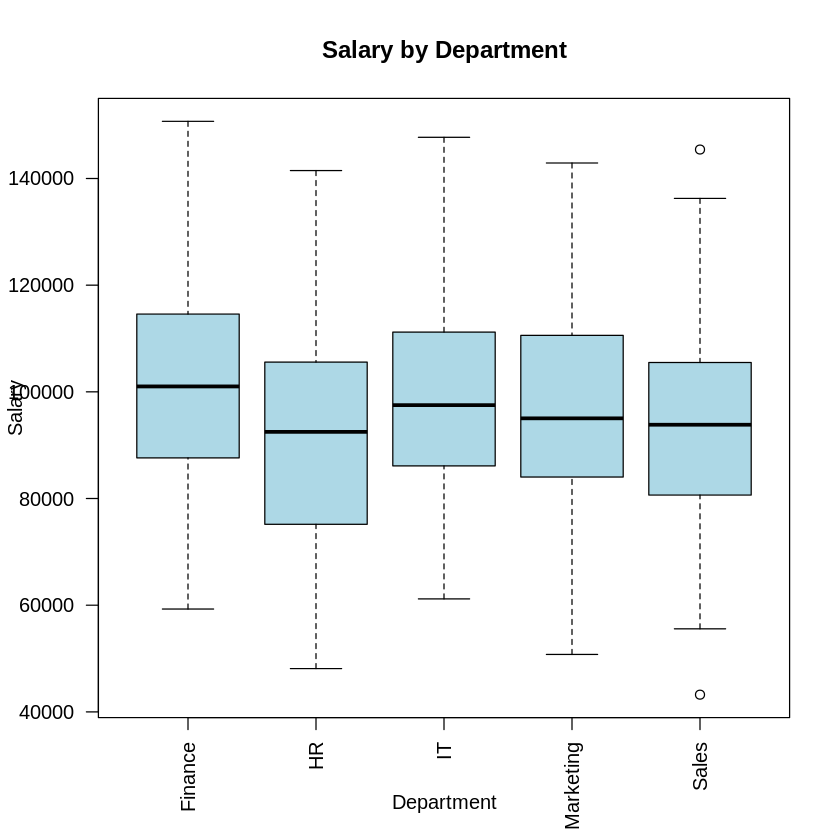

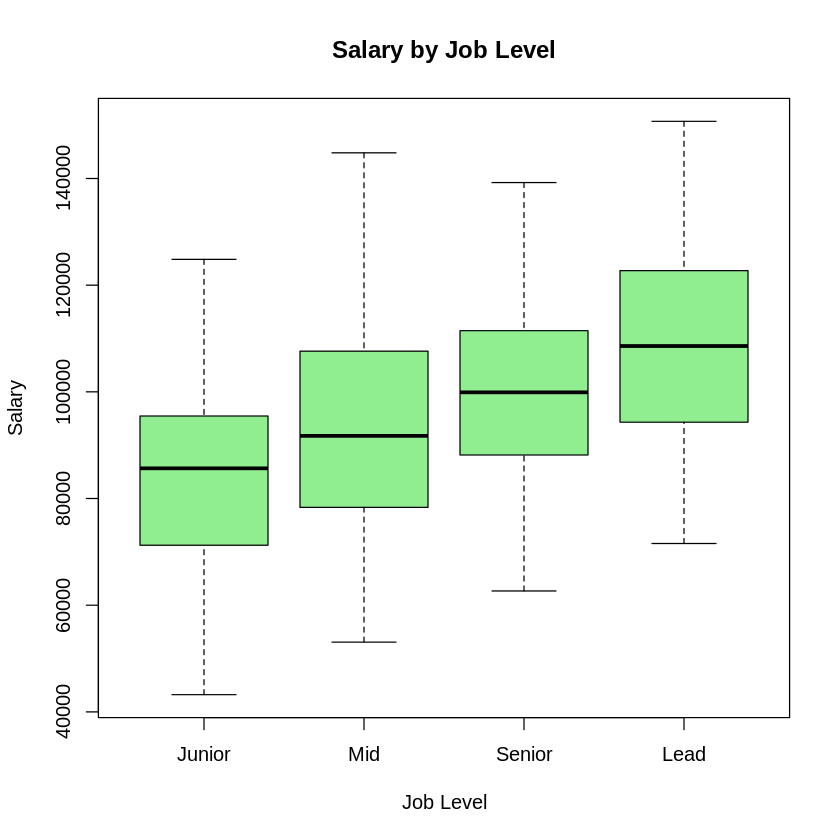

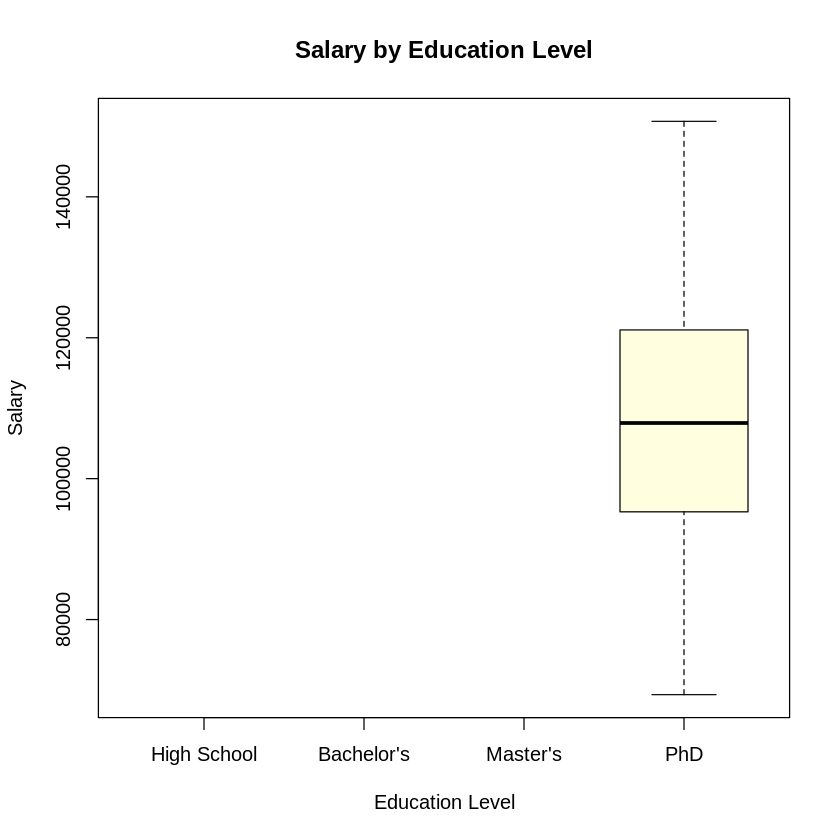

,Salary,ExperienceYears,TrainingHours,PerformanceRating,Age,ProjectsCompleted
Salary,1.00000000,0.622043590,0.08710779,0.18048721,-0.08060938,0.160464091
ExperienceYears,0.62204359,1.000000000,-0.02976172,0.03922046,-0.04465521,-0.007138014
TrainingHours,0.08710779,-0.029761715,1.00000000,0.04160003,-0.05256923,-0.064169908
PerformanceRating,0.18048721,0.039220463,0.04160003,1.00000000,-0.01374590,-0.053267778
Age,-0.08060938,-0.044655213,-0.05256923,-0.01374590,1.00000000,0.016436122
ProjectsCompleted,0.16046409,-0.007138014,-0.06416991,-0.05326778,0.01643612,1.000000000


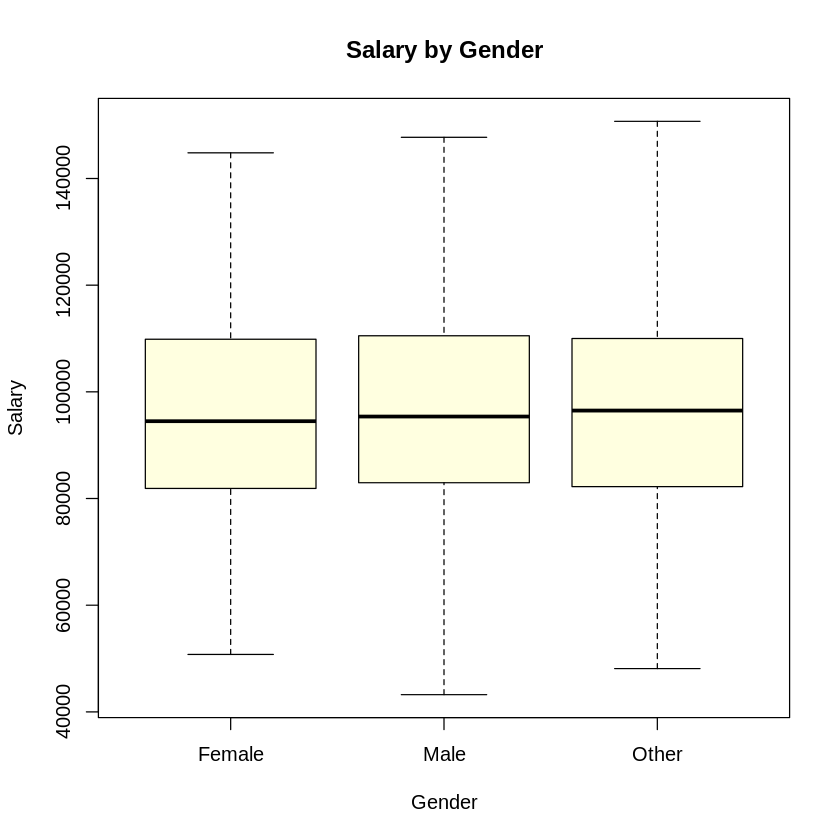

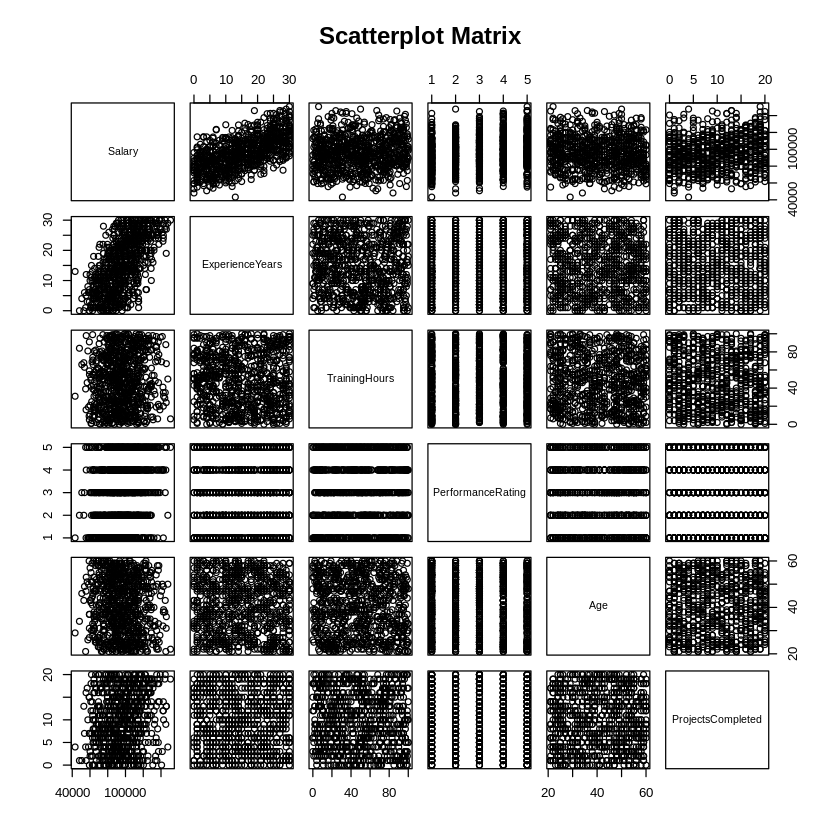

In [ ]:
par(mfrow = c(2, 2))
hist(df$Salary, main = "Salary Distribution", xlab = "Salary", col = "steelblue")
hist(df$ExperienceYears, main = "Experience Distribution", xlab = "Years", col = "steelblue")
hist(df$TrainingHours, main = "Training Hours Distribution", xlab = "Hours", col = "steelblue")
hist(df$Age, main = "Age Distribution", xlab = "Age", col = "steelblue")
par(mfrow = c(1, 1))

boxplot(Salary ~ Department, data = df, main = "Salary by Department",
        xlab = "Department", ylab = "Salary", col = "lightblue", las = 2)

boxplot(Salary ~ JobLevel, data = df, main = "Salary by Job Level",
        xlab = "Job Level", ylab = "Salary", col = "lightgreen")

boxplot(Salary ~ EducationLevel, data = df, main = "Salary by Education Level",
        xlab = "Education Level", ylab = "Salary", col = "lightyellow")

boxplot(Salary ~ Gender, data = df, main = "Salary by Gender",
        xlab = "Gender", ylab = "Salary", col = "lightyellow")

num_vars = df[, c("Salary", "ExperienceYears", "TrainingHours", "PerformanceRating", "Age", "ProjectsCompleted")]
cor(num_vars)
pairs(num_vars, main = "Scatterplot Matrix")

## Cell 4 — Simple Linear Regression

Simple Linear Regression models the relationship between one predictor
and one response variable. The goal is to fit a straight line through
the data that best explains how Salary changes as Experience Years increases.

The model takes the form:

    Salary = B0 + B1 * ExperienceYears + error

Where:
- B0 is the intercept (expected salary at zero years of experience)
- B1 is the slope (how much salary increases per additional year of experience)
- error captures the variation not explained by the model

Based on our EDA, ExperienceYears had the strongest positive linear
relationship with Salary, making it the most suitable predictor for
this model.

After fitting the model, we check:
- Coefficient significance (p-value < 0.05)
- R-squared (how much variance in Salary is explained)
- Residual plots to verify regression assumptions


Call:
lm(formula = Salary ~ ExperienceYears, data = df)

Residuals:
   Min     1Q Median     3Q    Max 
-50132 -11477    211  10239  44295 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     75494.65    1077.85   70.04   <2e-16 ***
ExperienceYears  1374.10      61.65   22.29   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15380 on 787 degrees of freedom
Multiple R-squared:  0.3869,	Adjusted R-squared:  0.3862 
F-statistic: 496.7 on 1 and 787 DF,  p-value: < 2.2e-16


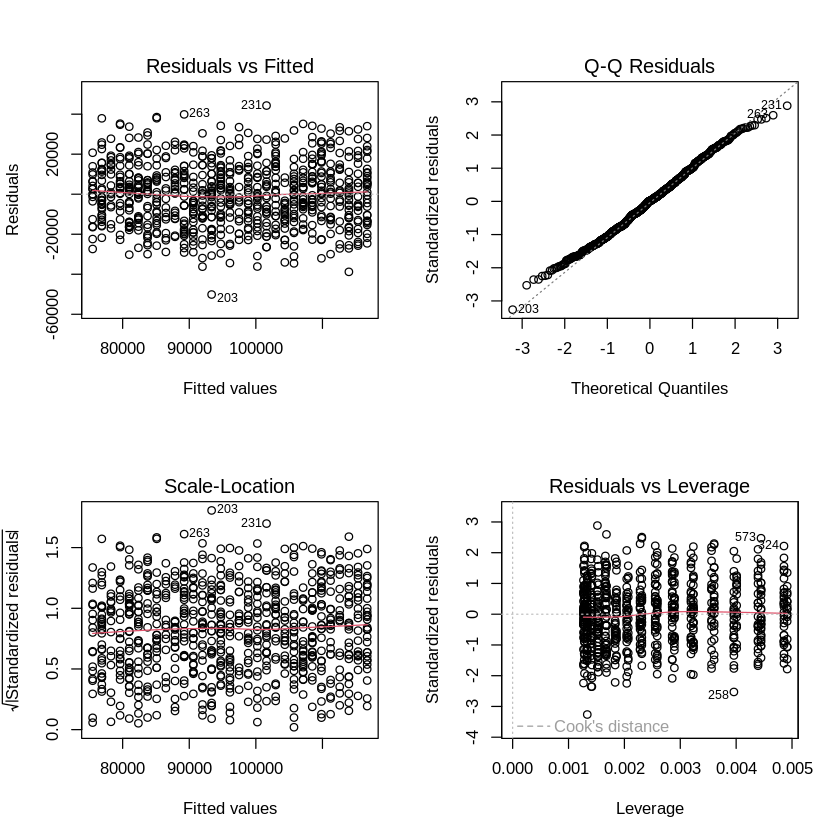

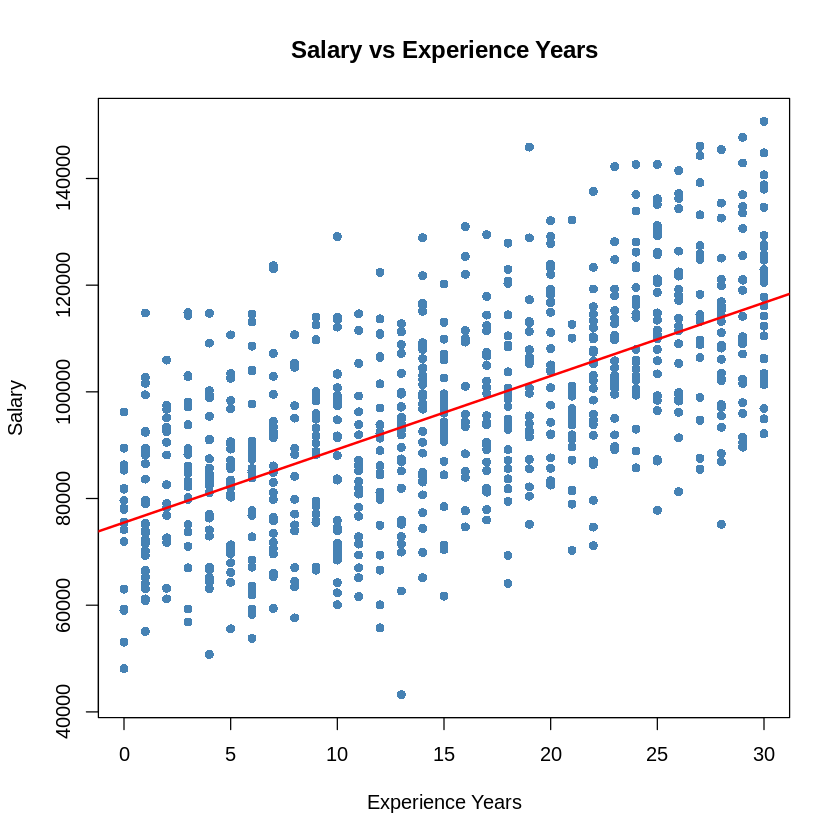

In [ ]:
slr_model = lm(Salary ~ ExperienceYears, data = df)

summary(slr_model)

par(mfrow = c(2, 2))
plot(slr_model)
par(mfrow = c(1, 1))

plot(df$ExperienceYears, df$Salary,
     main = "Salary vs Experience Years",
     xlab = "Experience Years",
     ylab = "Salary",
     col = "steelblue",
     pch = 16)
abline(slr_model, col = "red", lwd = 2)

## ANOVA

Analysis of Variance (ANOVA) tests whether the mean salary differs
significantly across groups of a categorical variable. Instead of
comparing two groups like a t-test, ANOVA handles three or more groups
at once.

The hypothesis being tested:

- Null Hypothesis (H0): The mean salary is the same across all Job Levels
- Alternative Hypothesis (H1): At least one Job Level has a different mean salary

The model takes the form:

    Salary ~ JobLevel

Job Level was selected as the grouping variable because the EDA boxplots
showed the clearest and most consistent salary differences across its
four levels: Junior, Mid, Senior, and Lead.

If the overall ANOVA F-test is significant (p-value < 0.05), a
Tukey HSD post-hoc test is performed to identify exactly which
pairs of Job Levels differ from each other.

Assumptions checked:
- Independence of observations
- Normality of residuals within each group
- Homogeneity of variance across groups (Bartlett's test)

             Df    Sum Sq   Mean Sq F value Pr(>F)    
JobLevel      3 6.605e+10 2.202e+10   72.79 <2e-16 ***
Residuals   785 2.375e+11 3.025e+08                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Salary ~ JobLevel, data = df)

$JobLevel
                   diff       lwr      upr    p adj
Mid-Junior     7693.363  3165.147 12221.58 8.15e-05
Senior-Junior 15358.582 10962.118 19755.05 0.00e+00
Lead-Junior   24567.803 20090.547 29045.06 0.00e+00
Senior-Mid     7665.219  3111.361 12219.08 9.75e-05
Lead-Mid      16874.440 12242.535 21506.34 0.00e+00
Lead-Senior    9209.221  4706.033 13712.41 1.10e-06



	Bartlett test of homogeneity of variances

data:  Salary by JobLevel
Bartlett's K-squared = 7.211, df = 3, p-value = 0.06547


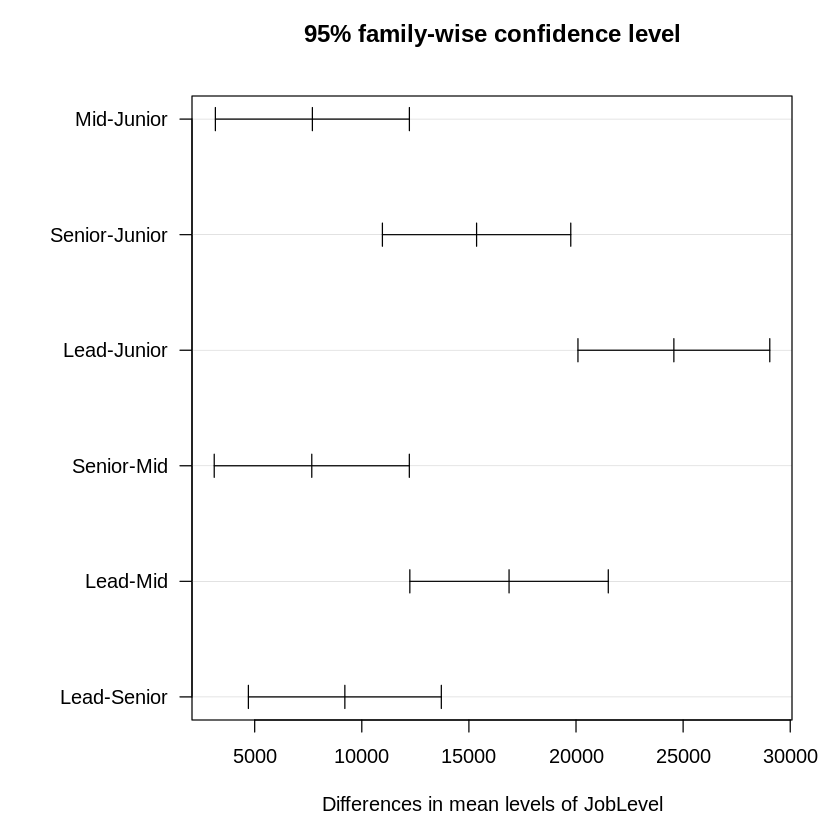

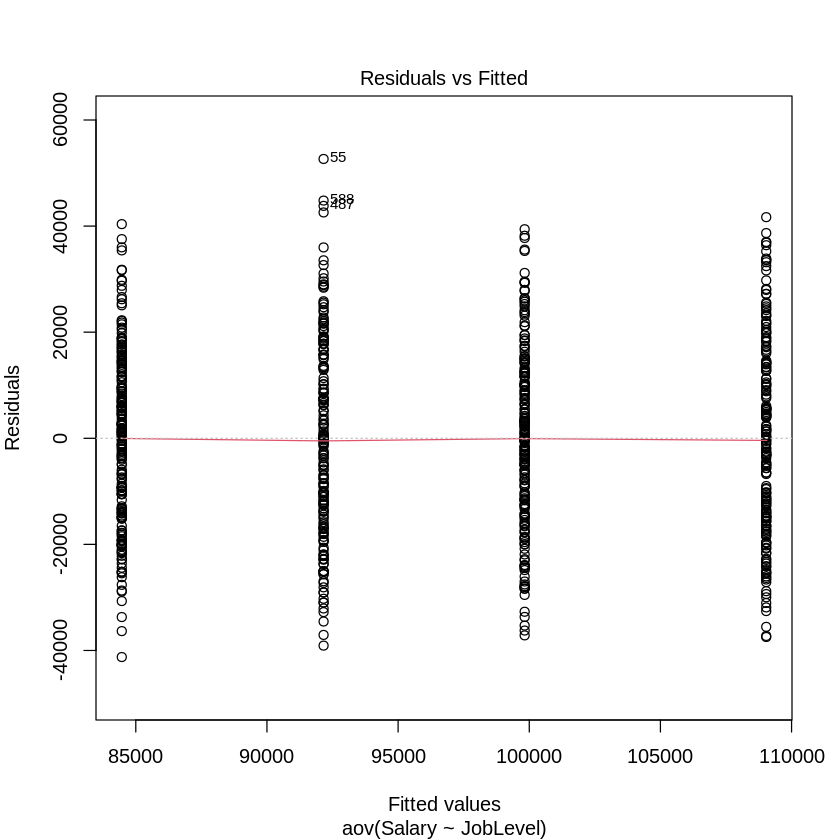

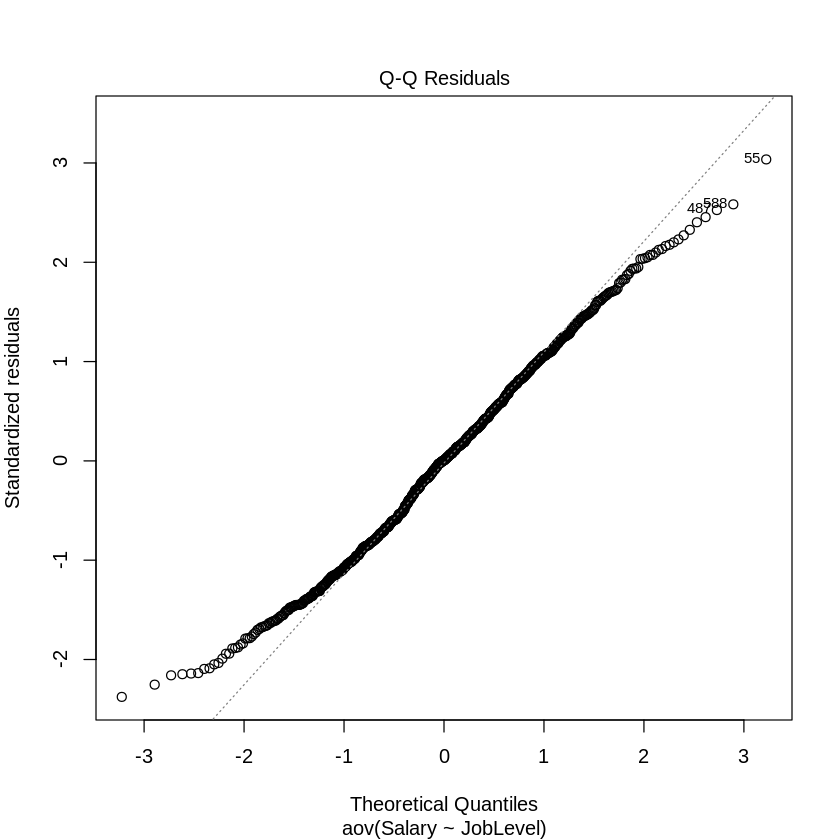

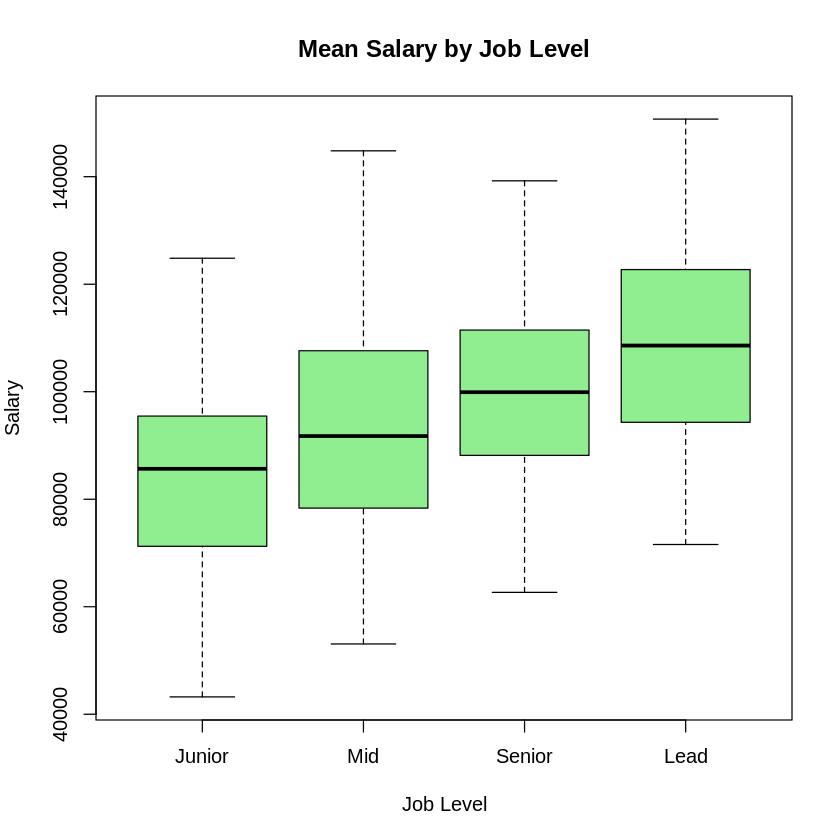

In [ ]:
df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

df$EducationLevel = factor(df$EducationLevel, levels = c("High School", "Bachelor's", "Master's", "PhD"))
df$JobLevel = factor(df$JobLevel, levels = c("Junior", "Mid", "Senior", "Lead"))
df$Department = factor(df$Department)
df$Gender = factor(df$Gender)

anova_model = aov(Salary ~ JobLevel, data = df)

summary(anova_model)

tukey_result = TukeyHSD(anova_model)
tukey_result

par(mar = c(5, 8, 4, 2))
plot(tukey_result, las = 1)

bartlett.test(Salary ~ JobLevel, data = df)

par(mar = c(5, 4, 4, 2))
plot(anova_model, which = 1)
plot(anova_model, which = 2)
par(mfrow = c(1, 1))

boxplot(Salary ~ JobLevel, data = df,
        main = "Mean Salary by Job Level",
        xlab = "Job Level",
        ylab = "Salary",
        col = "lightgreen")

## Cell 6 — Multiple Regression

Multiple Regression extends Simple Linear Regression by including more
than one predictor variable. This allows the model to capture the
combined effect of several factors on Salary simultaneously.

The model takes the form:

    Salary = B0 + B1*ExperienceYears + B2*Age + B3*TrainingHours
             + B4*PerformanceRating + B5*ProjectsCompleted + error

Where each coefficient represents the change in Salary for a one-unit
increase in that predictor, while holding all other predictors constant.

The goals of this analysis are:

- Identify which numeric predictors significantly affect Salary
- Check whether adding more predictors improves on the Simple Linear
  Regression model (compare R-squared values)
- Check for multicollinearity among predictors using VIF scores

VIF (Variance Inflation Factor) interpretation:
- VIF < 5: No multicollinearity concern
- VIF 5 to 10: Moderate concern
- VIF > 10: Serious multicollinearity, predictor should be reconsidered

After fitting the model, residual plots are examined to verify that
the assumptions of linearity, normality, and equal variance still hold.


Call:
lm(formula = Salary ~ ExperienceYears + Age + TrainingHours + 
    PerformanceRating + ProjectsCompleted, data = employee_df)

Residuals:
   Min     1Q Median     3Q    Max 
-42101 -10622     15   9916  39102 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       63127.00    2670.45  23.639  < 2e-16 ***
ExperienceYears    1365.38      58.37  23.392  < 2e-16 ***
Age                 -79.48      43.67  -1.820   0.0691 .  
TrainingHours        72.48      17.79   4.074 5.09e-05 ***
PerformanceRating  2171.22     357.15   6.079 1.89e-09 ***
ProjectsCompleted   584.24      85.32   6.848 1.51e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14520 on 783 degrees of freedom
Multiple R-squared:  0.4558,	Adjusted R-squared:  0.4524 
F-statistic: 131.2 on 5 and 783 DF,  p-value: < 2.2e-16


           Variable      VIF
1   ExperienceYears 1.004688
2               Age 1.005171
3     TrainingHours 1.009429
4 PerformanceRating 1.006021
5 ProjectsCompleted 1.006928


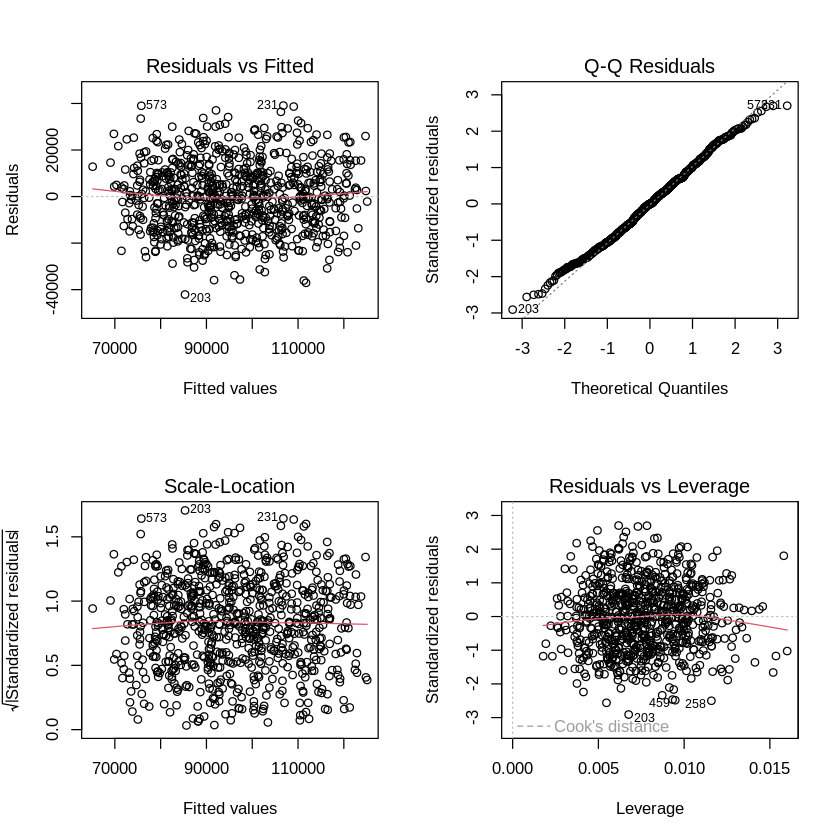

In [ ]:
employee_df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

employee_df$EducationLevel = factor(employee_df$EducationLevel, levels = c("High School", "Bachelor's", "Master's", "PhD"))
employee_df$JobLevel = factor(employee_df$JobLevel, levels = c("Junior", "Mid", "Senior", "Lead"))
employee_df$Department = factor(employee_df$Department)
employee_df$Gender = factor(employee_df$Gender)

mlr_model = lm(Salary ~ ExperienceYears + Age + TrainingHours +
               PerformanceRating + ProjectsCompleted, data = employee_df)

summary(mlr_model)

vif_values = 1 / (1 - summary(lm(ExperienceYears ~ Age + TrainingHours +
             PerformanceRating + ProjectsCompleted, data = employee_df))$r.squared)

vif_results = data.frame(
  Variable = c("ExperienceYears", "Age", "TrainingHours",
               "PerformanceRating", "ProjectsCompleted"),
  VIF = c(
    1 / (1 - summary(lm(ExperienceYears ~ Age + TrainingHours + PerformanceRating + ProjectsCompleted, data = employee_df))$r.squared),
    1 / (1 - summary(lm(Age ~ ExperienceYears + TrainingHours + PerformanceRating + ProjectsCompleted, data = employee_df))$r.squared),
    1 / (1 - summary(lm(TrainingHours ~ ExperienceYears + Age + PerformanceRating + ProjectsCompleted, data = employee_df))$r.squared),
    1 / (1 - summary(lm(PerformanceRating ~ ExperienceYears + Age + TrainingHours + ProjectsCompleted, data = employee_df))$r.squared),
    1 / (1 - summary(lm(ProjectsCompleted ~ ExperienceYears + Age + TrainingHours + PerformanceRating, data = employee_df))$r.squared)
  )
)

print(vif_results)

par(mfrow = c(2, 2))
plot(mlr_model)
par(mfrow = c(1, 1))

## Cell 7 — ANCOVA (Analysis of Covariance)

ANCOVA combines regression and ANOVA by including both a quantitative
predictor and a categorical predictor in the same model. The key idea
is to control for the effect of a continuous variable while testing
group differences.

The model takes the form:

    Salary = B0 + B1*ExperienceYears + B2*JobLevel + error

By including ExperienceYears as a covariate, this model asks whether
Job Level still has a significant effect on Salary after accounting
for years of experience. This is more informative than a plain ANOVA
because it removes the variation in salary that is already explained
by experience.

ExperienceYears was chosen as the covariate because it was the
strongest numeric predictor identified in the Simple Linear Regression.
JobLevel was chosen as the categorical factor because it showed the
most significant group differences in the ANOVA.

After fitting the model, the following are checked:
- Significance of both the quantitative and categorical predictors
- Whether R-squared improves compared to using either predictor alone
- Residual plots to verify model assumptions


Call:
lm(formula = Salary ~ ExperienceYears + JobLevel, data = employee_df)

Residuals:
   Min     1Q Median     3Q    Max 
-38911  -9199   -403   8741  32731 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     64382.02    1130.59  56.945  < 2e-16 ***
ExperienceYears  1365.80      49.96  27.336  < 2e-16 ***
JobLevelMid      7043.83    1259.54   5.592 3.09e-08 ***
JobLevelSenior  14269.11    1223.33  11.664  < 2e-16 ***
JobLevelLead    24357.64    1245.17  19.562  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 12450 on 784 degrees of freedom
Multiple R-squared:  0.5994,	Adjusted R-squared:  0.5974 
F-statistic: 293.3 on 4 and 784 DF,  p-value: < 2.2e-16


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ExperienceYears,1,117443567440,117443567440,757.3204,3.359302e-117
JobLevel,3,64495650406,21498550135,138.6308,4.662326e-72
Residuals,784,121580979997,155077781,NA,NA


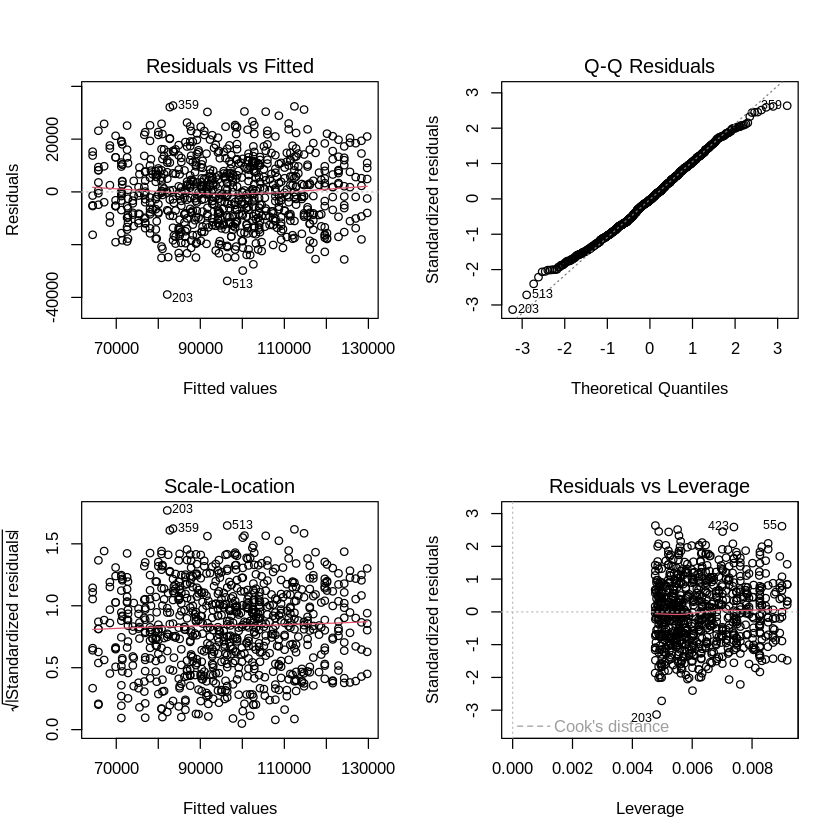

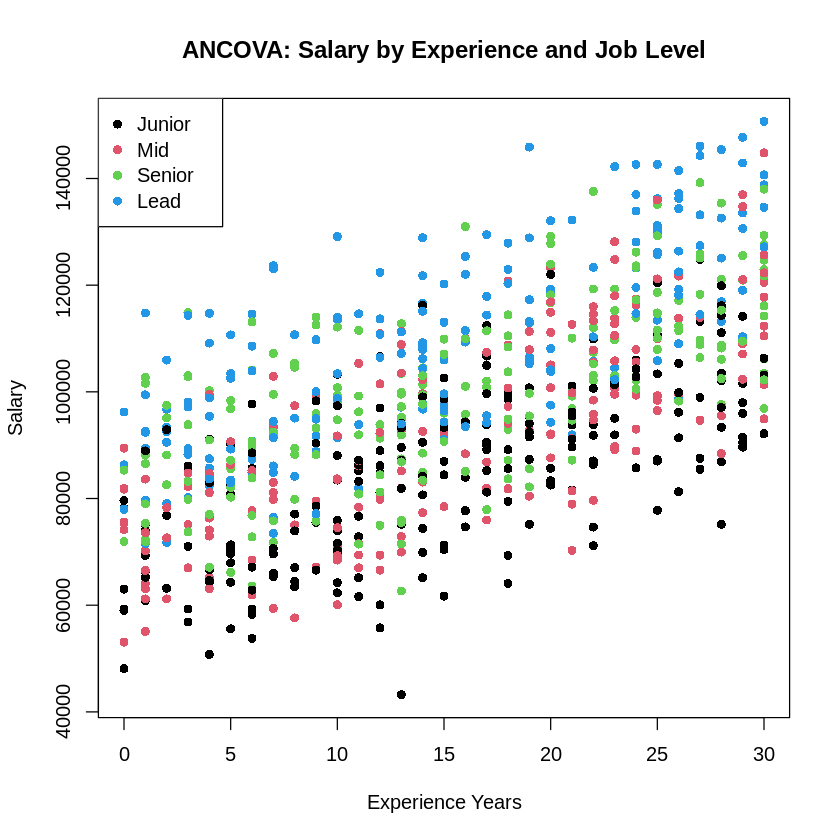

In [ ]:
employee_df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

employee_df$EducationLevel = factor(employee_df$EducationLevel, levels = c("High School", "Bachelor's", "Master's", "PhD"))
employee_df$JobLevel = factor(employee_df$JobLevel, levels = c("Junior", "Mid", "Senior", "Lead"))
employee_df$Department = factor(employee_df$Department)
employee_df$Gender = factor(employee_df$Gender)

ancova_model = lm(Salary ~ ExperienceYears + JobLevel, data = employee_df)

summary(ancova_model)

anova(ancova_model)

par(mfrow = c(2, 2))
plot(ancova_model)
par(mfrow = c(1, 1))

plot(employee_df$ExperienceYears, employee_df$Salary,
     col = as.numeric(employee_df$JobLevel),
     pch = 16,
     main = "ANCOVA: Salary by Experience and Job Level",
     xlab = "Experience Years",
     ylab = "Salary")

legend("topleft",
       legend = levels(employee_df$JobLevel),
       col = 1:4,
       pch = 16)

## Cell 8 — Interaction Model

An interaction model tests whether the effect of a quantitative
predictor on the response variable changes depending on the level
of a categorical variable. In other words, it asks whether the
slope of ExperienceYears on Salary is the same for all Job Levels,
or whether it differs across groups.

The model takes the form:

    Salary = B0 + B1*ExperienceYears + B2*JobLevel
             + B3*(ExperienceYears * JobLevel) + error

The interaction term ExperienceYears * JobLevel captures whether
the rate of salary growth per year of experience is different for
Junior, Mid, Senior, and Lead employees.

If the interaction is significant:
- The slope of experience on salary differs by job level
- Each group has its own regression line with a different steepness

If the interaction is not significant:
- The ANCOVA model without interaction is sufficient
- All groups share the same slope, only the intercepts differ

This model is compared against the ANCOVA model using anova() to
determine whether adding the interaction terms meaningfully improves
the model fit.


Call:
lm(formula = Salary ~ ExperienceYears * JobLevel, data = employee_df)

Residuals:
   Min     1Q Median     3Q    Max 
-39196  -9224     33   8871  32613 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    66836.15    1690.22  39.543  < 2e-16 ***
ExperienceYears                 1198.91      99.13  12.094  < 2e-16 ***
JobLevelMid                     1778.57    2475.70   0.718   0.4727    
JobLevelSenior                 13937.04    2419.62   5.760 1.21e-08 ***
JobLevelLead                   19828.92    2419.09   8.197 1.01e-15 ***
ExperienceYears:JobLevelMid      352.08     142.77   2.466   0.0139 *  
ExperienceYears:JobLevelSenior    30.01     138.50   0.217   0.8285    
ExperienceYears:JobLevelLead     306.52     140.53   2.181   0.0295 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 12400 on 781 degrees of freedom
Multiple R-squared:  0.6045,	Adjusted R-squared:  0

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,784,121580979997,NA,NA,NA,NA
2,781,120036152438,3,1544827559,3.350408,0.01862164


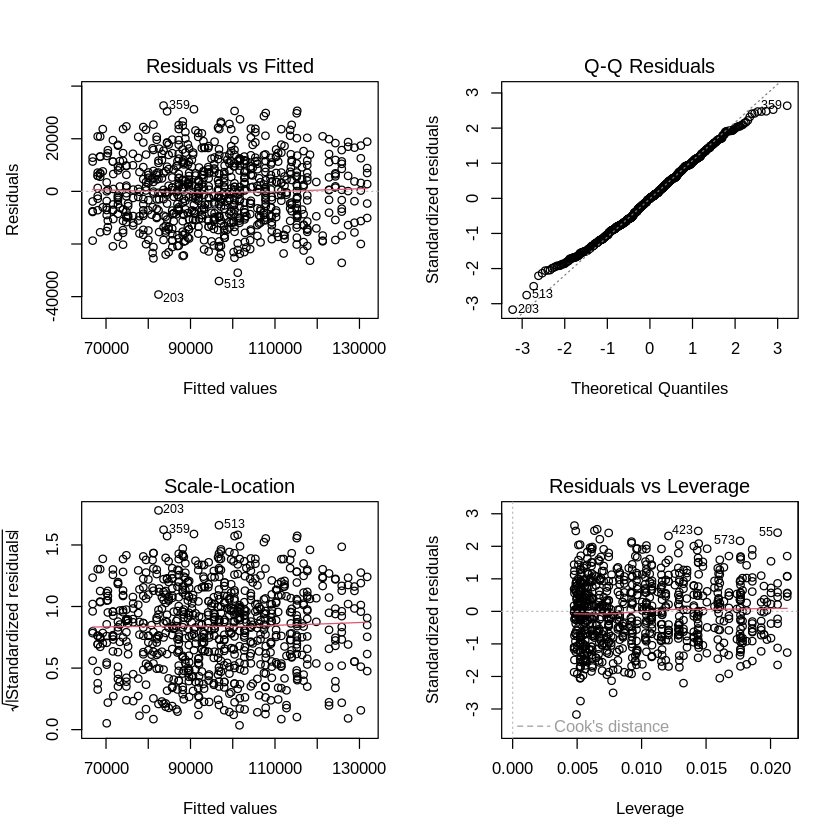

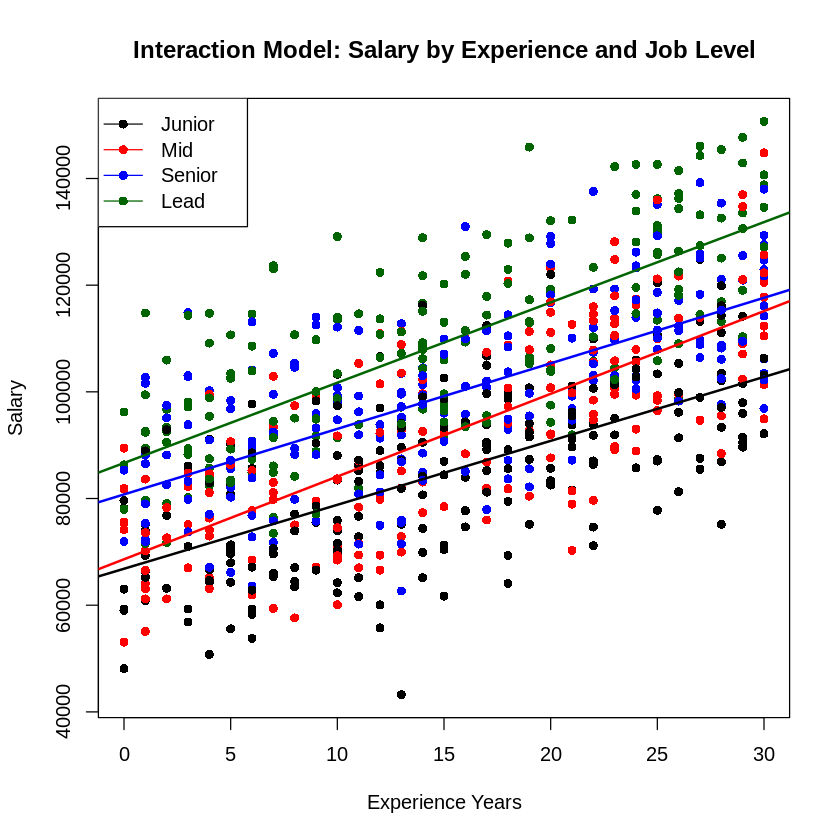

In [ ]:
employee_df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

employee_df$EducationLevel = factor(employee_df$EducationLevel, levels = c("High School", "Bachelor's", "Master's", "PhD"))
employee_df$JobLevel = factor(employee_df$JobLevel, levels = c("Junior", "Mid", "Senior", "Lead"))
employee_df$Department = factor(employee_df$Department)
employee_df$Gender = factor(employee_df$Gender)

interaction_model = lm(Salary ~ ExperienceYears * JobLevel, data = employee_df)

summary(interaction_model)

anova(ancova_model, interaction_model)

par(mfrow = c(2, 2))
plot(interaction_model)
par(mfrow = c(1, 1))

colors = c("black", "red", "blue", "darkgreen")

plot(employee_df$ExperienceYears, employee_df$Salary,
     col = colors[as.numeric(employee_df$JobLevel)],
     pch = 16,
     main = "Interaction Model: Salary by Experience and Job Level",
     xlab = "Experience Years",
     ylab = "Salary")

for(i in 1:4) {
  level = levels(employee_df$JobLevel)[i]
  subset_df = employee_df[employee_df$JobLevel == level, ]
  fit = lm(Salary ~ ExperienceYears, data = subset_df)
  abline(fit, col = colors[i], lwd = 2)
}

legend("topleft",
       legend = levels(employee_df$JobLevel),
       col = colors,
       pch = 16,
       lty = 1)

## Cell 9 — Model Comparison and Conclusion

This final cell brings together all models built throughout the analysis
and compares their performance. The goal is to identify which model best
explains salary variation and summarize the key findings from each
statistical method.

The models are compared using:
- R-squared: proportion of salary variation explained by the model
- Adjusted R-squared: R-squared penalized for adding extra predictors,
  more reliable for comparing models with different numbers of predictors
- Residual Standard Error: average prediction error in dollars,
  lower is better

A lower residual standard error and higher adjusted R-squared together
indicate a stronger, more reliable model.

                     Model
1 Simple Linear Regression
2      Multiple Regression
3                   ANCOVA
4        Interaction Model
                                                                     Predictors
1                                                               ExperienceYears
2 ExperienceYears + Age + TrainingHours + PerformanceRating + ProjectsCompleted
3                                                    ExperienceYears + JobLevel
4                                                    ExperienceYears * JobLevel
  R_Squared Adj_R_Squared      RSE
1    0.3869        0.3862 15376.54
2    0.4558        0.4524 14523.65
3    0.5994        0.5974 12453.02
4    0.6045        0.6010 12397.40


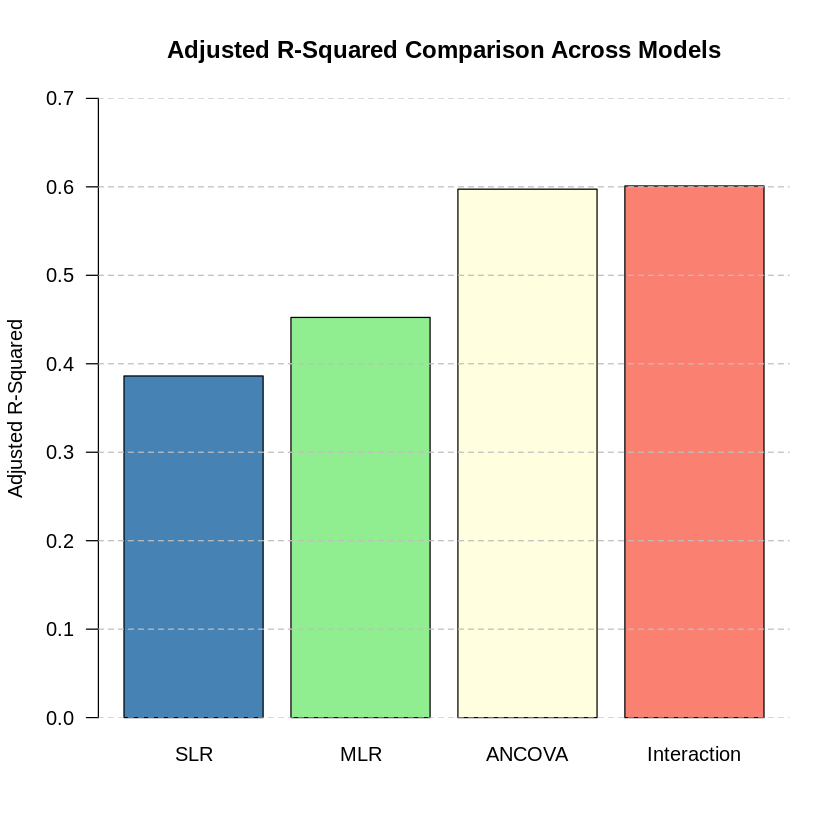

In [ ]:
employee_df = read.csv("extended_dataset_789.csv", stringsAsFactors = TRUE)

employee_df$EducationLevel = factor(employee_df$EducationLevel, levels = c("High School", "Bachelor's", "Master's", "PhD"))
employee_df$JobLevel = factor(employee_df$JobLevel, levels = c("Junior", "Mid", "Senior", "Lead"))
employee_df$Department = factor(employee_df$Department)
employee_df$Gender = factor(employee_df$Gender)

slr_model = lm(Salary ~ ExperienceYears, data = employee_df)
mlr_model = lm(Salary ~ ExperienceYears + Age + TrainingHours +
               PerformanceRating + ProjectsCompleted, data = employee_df)
ancova_model = lm(Salary ~ ExperienceYears + JobLevel, data = employee_df)
interaction_model = lm(Salary ~ ExperienceYears * JobLevel, data = employee_df)

model_comparison = data.frame(
  Model = c(
    "Simple Linear Regression",
    "Multiple Regression",
    "ANCOVA",
    "Interaction Model"
  ),
  Predictors = c(
    "ExperienceYears",
    "ExperienceYears + Age + TrainingHours + PerformanceRating + ProjectsCompleted",
    "ExperienceYears + JobLevel",
    "ExperienceYears * JobLevel"
  ),
  R_Squared = round(c(
    summary(slr_model)$r.squared,
    summary(mlr_model)$r.squared,
    summary(ancova_model)$r.squared,
    summary(interaction_model)$r.squared
  ), 4),
  Adj_R_Squared = round(c(
    summary(slr_model)$adj.r.squared,
    summary(mlr_model)$adj.r.squared,
    summary(ancova_model)$adj.r.squared,
    summary(interaction_model)$adj.r.squared
  ), 4),
  RSE = round(c(
    summary(slr_model)$sigma,
    summary(mlr_model)$sigma,
    summary(ancova_model)$sigma,
    summary(interaction_model)$sigma
  ), 2)
)

print(model_comparison)

barplot(
  model_comparison$Adj_R_Squared,
  names.arg = c("SLR", "MLR", "ANCOVA", "Interaction"),
  main = "Adjusted R-Squared Comparison Across Models",
  ylab = "Adjusted R-Squared",
  col = c("steelblue", "lightgreen", "lightyellow", "salmon"),
  ylim = c(0, 0.7),
  las = 1
)

abline(h = seq(0, 0.7, by = 0.1), col = "gray", lty = 2)